# Physical Design Automation: Accelerating Chip Layout Optimization using Machine Learning

## 1. Problem Statement & Background
In the semiconductor industry, the physical design stage of a chip—translating architectural specifications into a physical hardware layout—is incredibly time-consuming. Modern Electronic Design Automation (EDA) software suites can take days to process inputs, place components, and route wires for a single layout. 

A major bottleneck in this pipeline is its iterative, "black-box" nature: engineers can only evaluate whether a physical layout is acceptable (in terms of area, timing, and power constraints) after the execution run completes entirely. If the final output is suboptimal or violates design rules, engineers must manually adjust architectural inputs, modify design constraints, and restart the multi-day synthesis process from scratch. This drastically slows down the time-to-market for new silicon chips.

## 2. Project Objective & Proposed Solution
To bypass this costly feedback loop, this project introduces a Machine Learning approach to act as a fast predictive proxy for EDA software. By predicting layout characteristics early in the design cycle, we can enable real-time architectural exploration without waiting for full physical implementation.

Specifically, this notebook implements a **Random Forest Regressor** to predict the final core layout area (`design__core__area`) based on early design features, such as technology nodes, standard cell counts, and instance areas. 

* **Data Scope Note:** While ideal industry datasets capturing explicit user-targeted constraints (e.g., targeted clock frequency, targeted utilization percentages) are often proprietary, this project leverages a highly representative architectural dataset. Instead of using raw user target inputs, the model maps the structural properties and specific configurations of different chip design families directly to their final physical footprints. This demonstrates a viable proof-of-concept for accelerating physical design verification pipelines.

In [47]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data Loading, Subsetting, and Cleaning

Before feeding the dataset into our preprocessing pipeline, we load the raw data, extract the specific subsets/features relevant to predicting the physical chip layout area, and drop any incomplete records to ensure robust model training.

In [48]:
data_location = "final_parsed_metrics.csv"

data = pd.read_csv(data_location)
data.head(5)
# print(data.shape)

,name of circuit,tech node,antenna__violating__nets,antenna__violating__pins,clock__skew__worst_hold,clock__skew__worst_setup,design__core__area,design__core__bbox,design__critical_disconnected_pin__count,design__die__area,...,timing__hold_r2r_vio__count,timing__hold_vio__count,timing__setup__tns,timing__setup__wns,timing__setup__ws,timing__setup_r2r__ws,timing__setup_r2r_vio__count,timing__setup_vio__count,timing__unannotated_net__count,timing__unannotated_net_filtered__count
0,APU,180nm,0.0,0.0,0.733007,0.260119,284217.000,6.72 15.68 539.84 548.8,0.0,308622.0,...,0.0,0.0,0.0,0.0,43.257347,50.304146,0.0,0.0,0.0,0.0
1,blink,180nm,0.0,0.0,-0.003560,-0.008334,6146.560,6.72 15.68 85.12 94.08,0.0,10108.6,...,0.0,0.0,0.0,0.0,0.065277,0.065277,0.0,0.0,0.0,0.0
2,cell_inverter,180nm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,inverter,180nm,0.0,0.0,NaN,NaN,570.752,6.72 15.68 43.12 31.36,NaN,2500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,latch_bad,180nm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
# print(data.columns)
area_data = data[[
    'tech node',
    'name of circuit',
    'design__instance__area',
    'design__instance__area__macros',
    'design__instance__area__stdcell',
    'design__io',
    'design__instance__count',
    'design__instance__count__stdcell',
    'design__instance__count__macros',
    'design__inferred_latch__count',
    'design__instance__count__hold_buffer',
    'design__instance__count__setup_buffer',
    'design__core__area']]
# area_data.head(5)

In [50]:
area_data = area_data.dropna(subset=['design__instance__count', 'design__core__area'], how='any')
zero_instance = area_data[area_data['design__instance__count'] == 0]
area_data = area_data.dropna(subset=['design__instance__count__hold_buffer', 'design__instance__count__macros', 'design__instance__count__setup_buffer', 'design__instance__count__stdcell', 'design__inferred_latch__count'], how='any')

print(zero_instance.shape)
print(area_data.shape)
print(area_data.isna().any())
area_data.head(5)

(0, 13)
(20821, 13)
tech node                                False
name of circuit                          False
design__instance__area                   False
design__instance__area__macros           False
design__instance__area__stdcell          False
design__io                               False
design__instance__count                  False
design__instance__count__stdcell         False
design__instance__count__macros          False
design__inferred_latch__count            False
design__instance__count__hold_buffer     False
design__instance__count__setup_buffer    False
design__core__area                       False
dtype: bool


,tech node,name of circuit,design__instance__area,design__instance__area__macros,design__instance__area__stdcell,design__io,design__instance__count,design__instance__count__stdcell,design__instance__count__macros,design__inferred_latch__count,design__instance__count__hold_buffer,design__instance__count__setup_buffer,design__core__area
0,180nm,APU,107602.0,0.0,107602.0,77.0,7130.0,7130.0,0.0,0.0,1.0,0.0,284217.0
6,180nm,spm,11621.4,0.0,11621.4,38.0,593.0,593.0,0.0,0.0,0.0,0.0,21280.3
7,180nm,usb,31501.1,0.0,31501.1,46.0,1361.0,1361.0,0.0,0.0,0.0,0.0,59885.1
8,180nm,usb_cdc_core,73679.7,0.0,73679.7,55.0,4230.0,4230.0,0.0,0.0,4.0,46.0,157640.0
9,180nm,wbqspiflash,67873.4,0.0,67873.4,106.0,3028.0,3028.0,0.0,0.0,0.0,39.0,94345.3


## 3. Exploratory Data Analysis (EDA) & Data Visualization

Before training our machine learning model, it is crucial to visually analyze our dataset to understand the underlying distributions and relationships between physical features. 

In this section, we utilize visualizations to investigate:
1. **Target Distribution:** Analyzing the distribution of our target variable (`design__core__area`) to look for skewness, outliers, or scale differences.
2. **Feature-to-Target Relationships:** Creating scatter plots to observe how continuous variables—such as the standard cell instance count and standard cell area—correlate with the final chip layout area. Because physical chip scaling is often non-linear, visualizing these patterns helps justify why an ensemble tree-based regressor (like Random Forest) is well-suited for this problem compared to simple linear models.
3. **Multicollinearity:** Identifying strong correlations between our independent features to ensure our preprocessing pipeline handles the feature space efficiently.

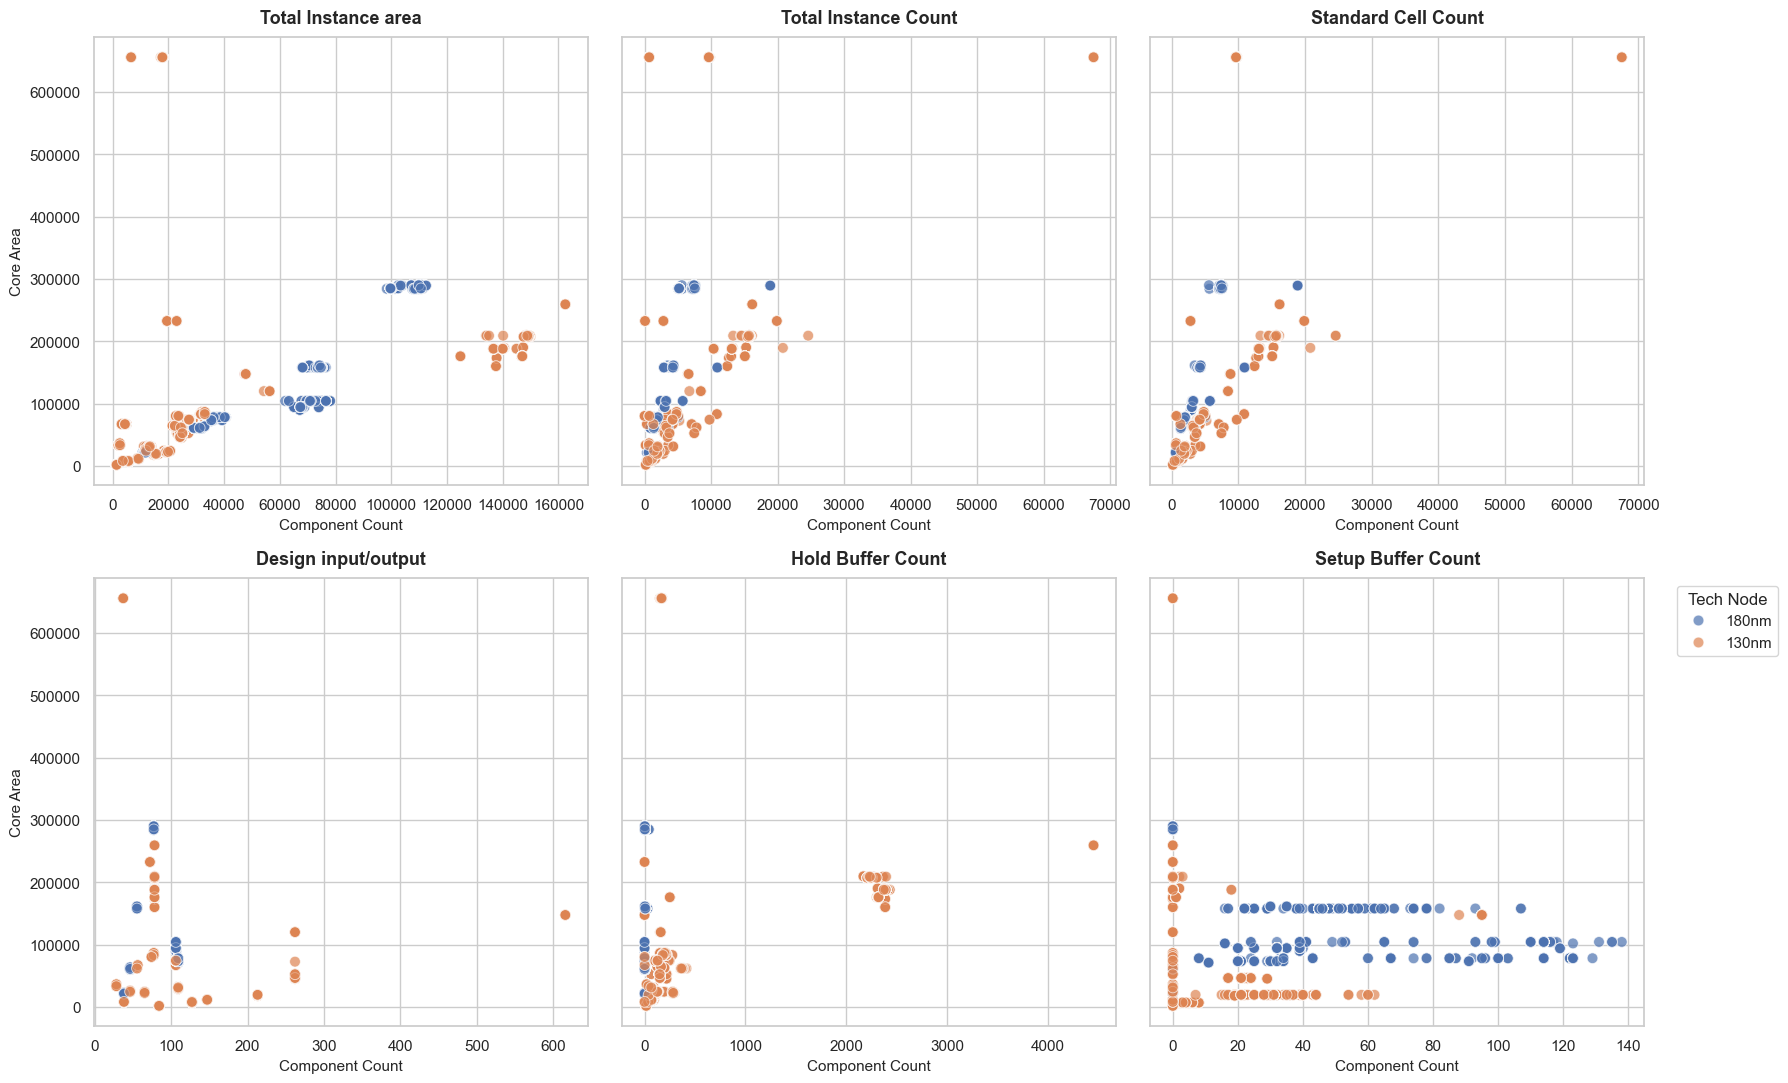

In [51]:
plot_config = [
    {"col": "design__instance__area", "title": "Total Instance area"},
    {"col": "design__instance__count", "title": "Total Instance Count"},
    {"col": "design__instance__count__stdcell", "title": "Standard Cell Count"},
    {"col": "design__io", "title": "Design input/output"},
    {"col": "design__instance__count__hold_buffer", "title": "Hold Buffer Count"},
    {"col": "design__instance__count__setup_buffer", "title": "Setup Buffer Count"},
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharey=True)
axes = axes.flatten()

for i, config in enumerate(plot_config):
    sns.scatterplot(
        data=area_data,
        x=config["col"],
        y="design__core__area",
        hue="tech node",  
        palette="deep",
        ax=axes[i], 
        s=60,
        alpha=0.7,
    )
    axes[i].set_title(config["title"], fontsize=13, fontweight="bold", pad=10)
    axes[i].set_xlabel("Component Count", fontsize=11)

    if i % 3 == 0:
        axes[i].set_ylabel("Core Area", fontsize=11)
    else:
        axes[i].set_ylabel("")

    if i != 5:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title="Tech Node", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

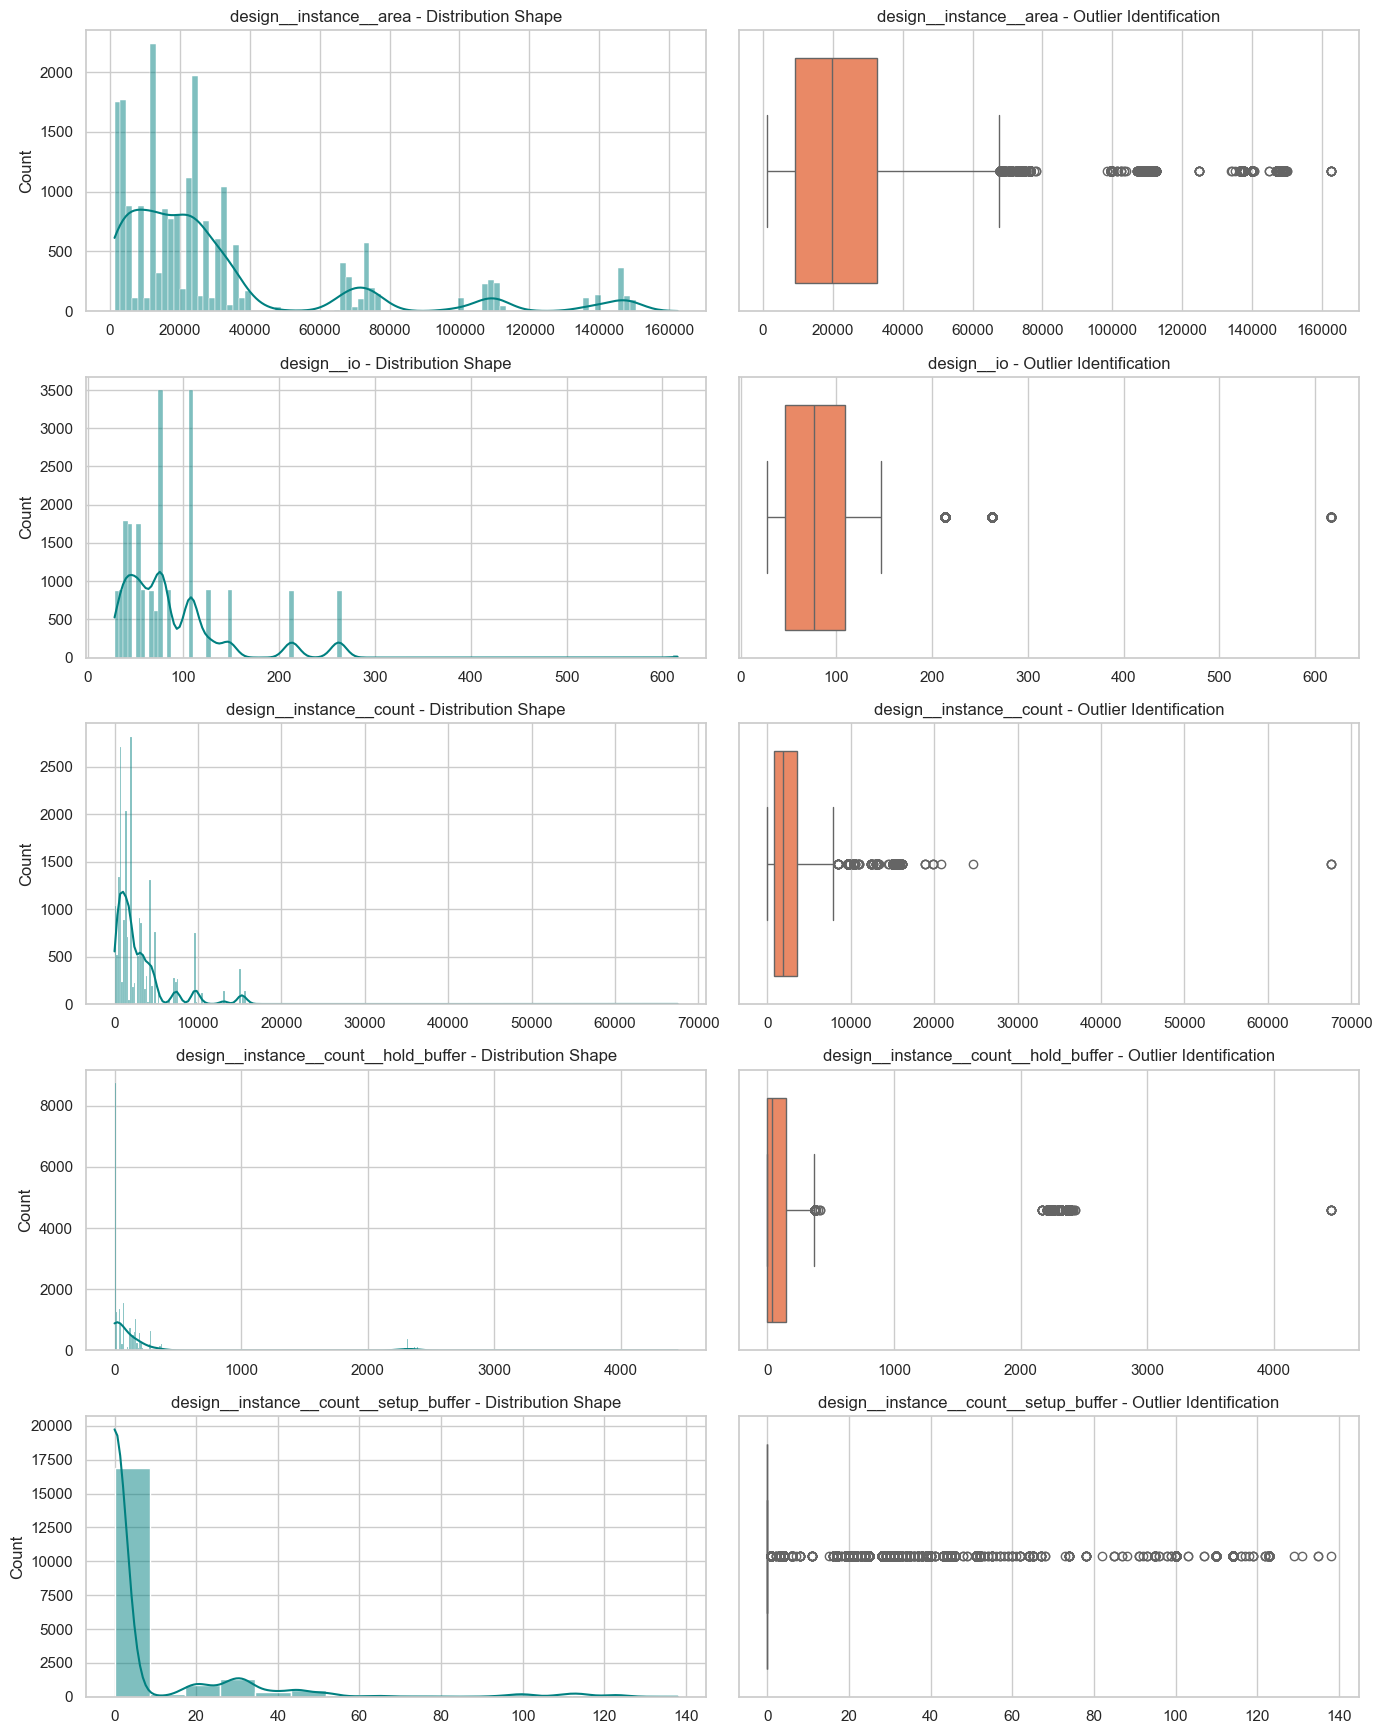

In [52]:
features_to_check = [
    'design__instance__area', 
    # 'design__instance__area__stdcell',
    # 'design__instance__area__macros',
    'design__io', 
    'design__instance__count',
    # 'design__instance__count__stdcell',
    # 'design__instance__count__macros',
    # 'design__inferred_latch__count',
    'design__instance__count__hold_buffer',
    'design__instance__count__setup_buffer'
]

fig, axes = plt.subplots(nrows=len(features_to_check), ncols=2, figsize=(14, 3.5 * len(features_to_check)))

for i, col in enumerate(features_to_check):
    sns.histplot(data=area_data, x=col, kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'{col} - Distribution Shape')
    axes[i, 0].set_xlabel('') 
    
    sns.boxplot(data=area_data, x=col, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'{col} - Outlier Identification')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

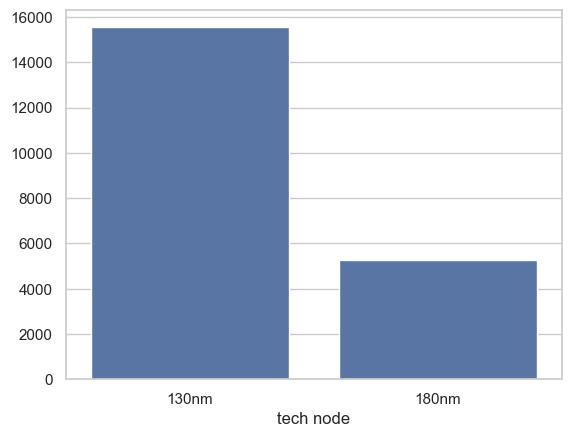

In [53]:
count = area_data['tech node'].value_counts()
sns.set_theme(style="whitegrid")
sns.barplot(x=count.index, y=count.values)
plt.show

## 4. Data Preprocessing: Encoding, Standardization, and Feature Selection

To prepare our raw dataset for training, we implement a robust preprocessing pipeline using scikit-learn's `ColumnTransformer` combined with a targeted feature selection strategy to eliminate redundant data.

### Preprocessing & Feature Engineering Strategy:

1. **Ordinal Encoding:** The feature `tech node` (e.g., 130nm vs. 180nm) contains inherent categorical orders representing chronological semiconductor process generations. We utilize an `OrdinalEncoder` to map these technology nodes into a sequential numeric scale safely.

2. **Feature Standardization:** Physical design attributes (such as cell counts and physical areas) span drastically different numeric ranges and metric scales. We apply a `StandardScaler` to continuous features to center their distribution around a mean of 0 with a standard deviation of 1. This prevents features with large absolute magnitudes from dominating the loss function and ensures balanced gradient updates.

3. **Multicollinearity Mitigation (Feature Selection):** During exploratory data analysis, a correlation matrix revealed severe multicollinearity between global and localized layout metrics:
   * `design__instance__area` was nearly perfectly correlated with `design__instance__area__stdcell`
   * `design__instance__count` was nearly perfectly correlated with `design__instance__count__stdcell`
   
   High multicollinearity heavily destabilizes Ordinary Least Squares (OLS) estimation in **Linear Regression** and inflates coefficients in **Polynomial Regression**, causing immense numerical instability and poor generalization performance. To eliminate this redundancy and protect our parametric baselines from overfitting, the global features (`design__instance__area` and `design__instance__count`) were deliberately dropped from the feature matrix, keeping only their standard-cell counterparts.

In [54]:
from sklearn.preprocessing import OrdinalEncoder

tech_node_categories = [['180nm', '130nm']]
ordinal_feature = ['tech node']
ordinal_encoder = OrdinalEncoder(categories=tech_node_categories)



In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

features_to_check = [
    # 'design__instance__area', 
    'design__instance__area__stdcell',
    'design__instance__area__macros',
    'design__io', 
    # 'design__instance__count',
    'design__instance__count__stdcell',
    'design__instance__count__macros',
    'design__inferred_latch__count',
    'design__instance__count__hold_buffer',
    'design__instance__count__setup_buffer'
]

ct = ColumnTransformer(transformers=[('ord', ordinal_encoder, ordinal_feature),
                                     ('num', StandardScaler(), features_to_check)])
ct.set_output(transform='pandas')

y = area_data['design__core__area']
x = area_data.drop(columns=['design__core__area'])

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, stratify=x['tech node'], random_state=148)

X_train_scaled = ct.fit_transform(X_train)
X_test_scaled = ct.transform(X_test)

X_train_scaled.head(5)


,ord__tech node,num__design__instance__area__stdcell,num__design__instance__area__macros,num__design__io,num__design__instance__count__stdcell,num__design__instance__count__macros,num__design__inferred_latch__count,num__design__instance__count__hold_buffer,num__design__instance__count__setup_buffer
749,1.0,-0.668595,-0.27767,0.642039,-0.698439,-0.278764,-0.21302,-0.274466,-0.391130
4660,1.0,-0.725309,-0.27767,-0.859096,-0.785526,-0.278764,-0.21302,-0.352915,-0.391130
24184,1.0,-0.387743,-0.27767,2.092574,-0.356878,-0.278764,-0.21302,-0.265749,1.079041
21703,1.0,-0.786894,-0.27767,-0.083229,-0.857558,-0.278764,-0.21302,-0.318049,-0.391130
8091,1.0,-0.247174,-0.27767,-0.403696,-0.256211,-0.278764,-0.21302,0.252888,-0.391130


## Correlation 

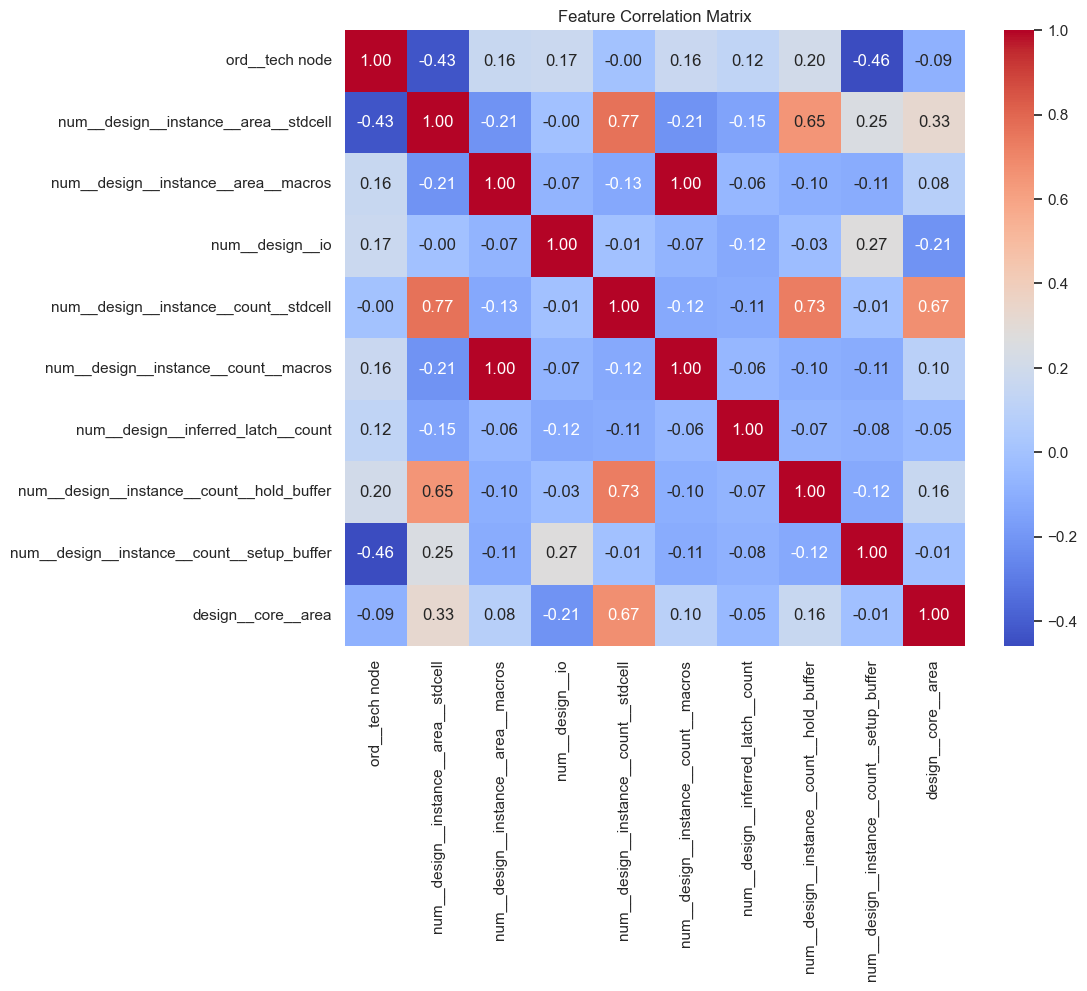

In [56]:
temp = pd.concat([X_train_scaled, Y_train], axis=1)
corr_matrix = temp.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

## 5. Model Training and Selection Strategy

To accurately predict the physical chip core layout area (`design__core__area`), we evaluate three distinct machine learning algorithms. This comparative approach allows us to bench-test baseline mathematical complexity against advanced non-linear regression estimators.

### Models Evaluated:
1. **Linear Regression:** * *Purpose:* Serves as our baseline model. It assumes a direct, proportional relationship between architectural inputs (like instance count) and the final physical footprint. 
   * *Limitation:* Physical layout geometry and routing overheads rarely scale in a strictly linear fashion, making this baseline prone to underfitting.
   
2. **Polynomial Regression (Degree 2):** * *Purpose:* Introduces non-linear feature interactions and curvature to our baseline (e.g., modeling $x^2$ growth trends). This helps capture early geometric scaling complexities inherent to circuit designs without moving to a black-box model.

3. **Random Forest Regressor (Ensemble Method):** * *Purpose:* An ensemble tree-based algorithm that constructs numerous parallel decision trees and averages their predictions. 
   * *Why it fits best:* Circuit layout features interact in highly complex, step-wise, and conditional ways (e.g., a specific instance count might behave radically differently on a 130nm node compared to a 180nm node). Random Forests naturally capture these conditional interactions, handle collinear features, and are highly resilient to overfitting.

In [57]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, Y_train)

y_predict = linear_model.predict(X_test_scaled)

mse = mean_squared_error(Y_test, y_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_predict)
r2 = r2_score(Y_test, y_predict)

print(f"MSE = {mse}\nRMSE = {rmse}\nMAE = {mae}\nR2 = {r2}")

MSE = 7416800248.235881
RMSE = 86120.8467691527
MAE = 29829.519201978084
R2 = 0.6267637310029959


In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

all_columns = X_train_scaled.columns.tolist()
numerical_cols = [col for col in all_columns if col != 'ord__tech node']
categorical_cols = ['ord__tech node']

numerical_transformer = PolynomialFeatures(degree=2, include_bias=False)

feature_expansion = ColumnTransformer(
    transformers=[
        ('poly_num', numerical_transformer, numerical_cols),
        ('cat', 'passthrough', categorical_cols)
    ]
)

pipeline = Pipeline([
    ('expansion', feature_expansion),
    ('regression', LinearRegression())
])

pipeline.fit(X_train_scaled, Y_train)


y_predict = pipeline.predict(X_test_scaled)

mse = mean_squared_error(Y_test, y_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_predict)
r2 = r2_score(Y_test, y_predict)

print(f"MSE = {mse}\nRMSE = {rmse}\nMAE = {mae}\nR2 = {r2}")

MSE = 400655344.1583374
RMSE = 20016.376898888007
MAE = 12354.392887516526
R2 = 0.9798377870776637


In [59]:
from sklearn.ensemble import RandomForestRegressor

tree_model = RandomForestRegressor(n_estimators=100, random_state=148)

tree_model.fit(X_train_scaled, Y_train)


y_predict = tree_model.predict(X_test_scaled)

mse = mean_squared_error(Y_test, y_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_predict)
r2 = r2_score(Y_test, y_predict)

print(f"MSE = {mse}\nRMSE = {rmse}\nMAE = {mae}\nR2 = {r2}")

MSE = 2029185.8905303983
RMSE = 1424.494959812213
MAE = 80.64587543822648
R2 = 0.9998978851060384


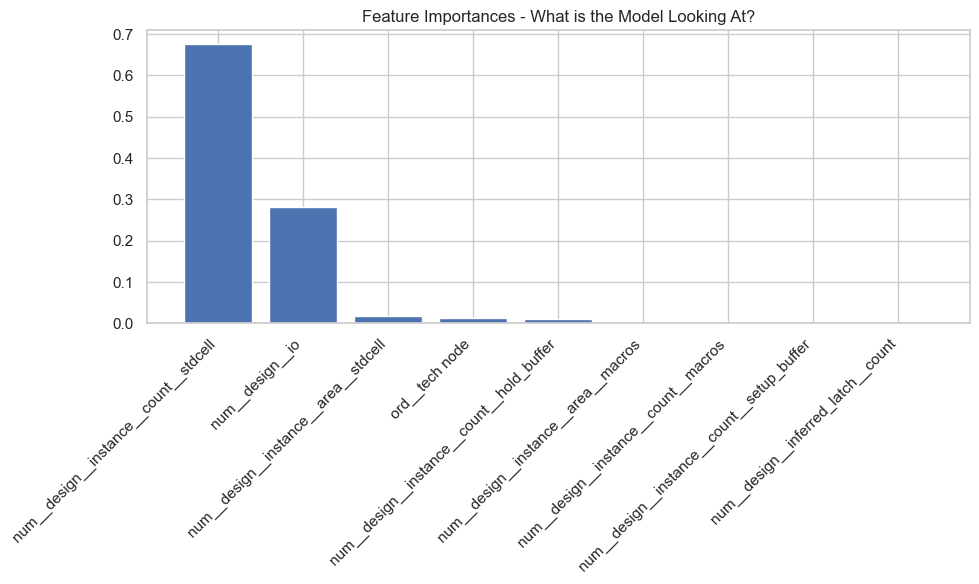

In [60]:
import numpy as np

# Extract feature importances from your trained random forest
importances = tree_model.feature_importances_
feature_names = X_train_scaled.columns

# Sort them in descending order
indices = np.argsort(importances)[::-1]

# Plot the top features
plt.figure(figsize=(10, 6))
plt.title("Feature Importances - What is the Model Looking At?")
plt.bar(range(X_train_scaled.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_scaled.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()